# Quadrupoles, the Gene Pool, and a Redox Electron-Transport Chain

Three topics, two new modules and one reuse of existing machinery:

1. **Electric quadrupole moments** (`dgs/electrostatics_multipoles.py`, new)
   -- the multipole expansion, with the classic four-point-charge quadrupole
   that has zero monopole and zero dipole by symmetry.
2. **The gene pool, quantitatively** (`dgs/population_genetics.py`, new) --
   Hardy-Weinberg equilibrium and Wright-Fisher genetic drift, the
   population-scale extension of the single-cross Punnett square in
   `dgs.cell_biology`.
3. **A redox electron-transport chain** -- built with ZERO new code, by
   reusing `dgs.photosynthesis_energy_transfer`'s rate-matrix machinery: an
   electron hopping donor -> intermediate -> acceptor is the exact same
   linear-ODE structure as FRET energy transfer between chromophores.

(Lennard-Jones $F=-\nabla U$, including its `+C` indefinite integral, is
already fully built and symbolically verified in `dgs/lennard_jones.py` --
nothing new needed there.)


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import electrostatics_multipoles as em
from dgs import population_genetics as pg
from dgs import photosynthesis_energy_transfer as pet

plt.rcParams["figure.dpi"] = 110


## 1. The classic charge quadrupole: zero monopole, zero dipole, pure quadrupole

Four alternating charges $+q,-q,+q,-q$ on a square: by symmetry the total
charge and dipole moment are exactly zero, so only the quadrupole term
survives in the multipole expansion of the potential.


monopole Q  = 0.0
dipole p    = [0. 0. 0.]
quadrupole Theta =
 [[ 0. 12.  0.]
 [12.  0.  0.]
 [ 0.  0.  0.]]
trace (must be 0): 0.0


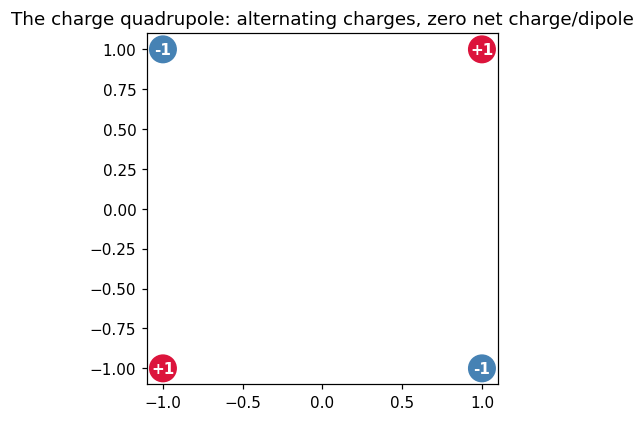

In [2]:
charges, positions = em.quadrupole_square_example(q=1.0, a=1.0)
print("monopole Q  =", em.monopole_moment(charges))
print("dipole p    =", em.dipole_moment(charges, positions))
Theta = em.quadrupole_moment(charges, positions)
print("quadrupole Theta =\n", Theta)
print("trace (must be 0):", np.trace(Theta))

fig, ax = plt.subplots(figsize=(4, 4))
colors = ["crimson" if c > 0 else "steelblue" for c in charges]
ax.scatter(positions[:, 0], positions[:, 1], c=colors, s=300)
for (x, y, _), c in zip(positions, charges):
    ax.annotate(f"{c:+.0f}", (x, y), ha="center", va="center", color="white", fontweight="bold")
ax.set_title("The charge quadrupole: alternating charges, zero net charge/dipole")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


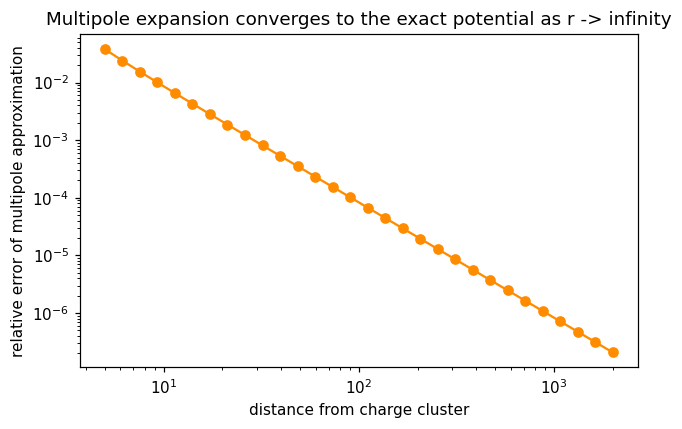

In [3]:
# multipole expansion accuracy improves with distance from the charges
radii = np.geomspace(5, 2000, 30)
rel_errors = []
for r in radii:
    fp = [r / np.sqrt(2), r / np.sqrt(2), 0.0]
    approx = em.multipole_potential(charges, positions, fp)["V_total"]
    exact = em.exact_potential(charges, positions, fp)
    rel_errors.append(abs(approx - exact) / abs(exact))

plt.figure(figsize=(6, 4))
plt.loglog(radii, rel_errors, "o-", color="darkorange")
plt.xlabel("distance from charge cluster")
plt.ylabel("relative error of multipole approximation")
plt.title("Multipole expansion converges to the exact potential as r -> infinity")
plt.tight_layout()
plt.show()


## 2. The gene pool: Hardy-Weinberg equilibrium and genetic drift

A "gene pool" is a probability distribution over alleles. Hardy-Weinberg
gives the equilibrium genotype frequencies $p^2{:}2pq{:}q^2$ under random
mating with no selection/drift/mutation; a small population deviates from
that prediction purely by chance (genetic drift), which Hardy-Weinberg's
infinite-population formula can't see.


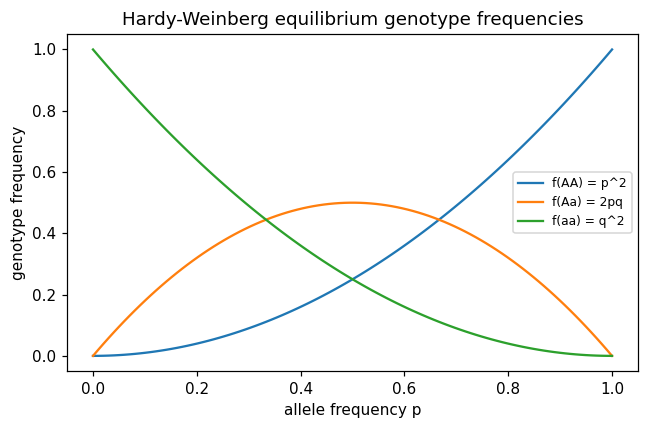

inbred-like population check: {'holds': False, 'max_deviation': 0.395, 'observed': {'AA': 0.4, 'Aa': 0.1, 'aa': 0.5}, 'expected': {'AA': 0.2025, 'Aa': 0.49500000000000005, 'aa': 0.30250000000000005}, 'p': 0.45}


In [4]:
p_values = np.linspace(0, 1, 100)
freqs = np.array([list(pg.hardy_weinberg_genotype_frequencies(p).values()) for p in p_values])

plt.figure(figsize=(6, 4))
plt.plot(p_values, freqs[:, 0], label="f(AA) = p^2")
plt.plot(p_values, freqs[:, 1], label="f(Aa) = 2pq")
plt.plot(p_values, freqs[:, 2], label="f(aa) = q^2")
plt.xlabel("allele frequency p"); plt.ylabel("genotype frequency")
plt.title("Hardy-Weinberg equilibrium genotype frequencies")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

inbred = {"AA": 40, "Aa": 10, "aa": 50}
print("inbred-like population check:", pg.hardy_weinberg_holds(inbred))


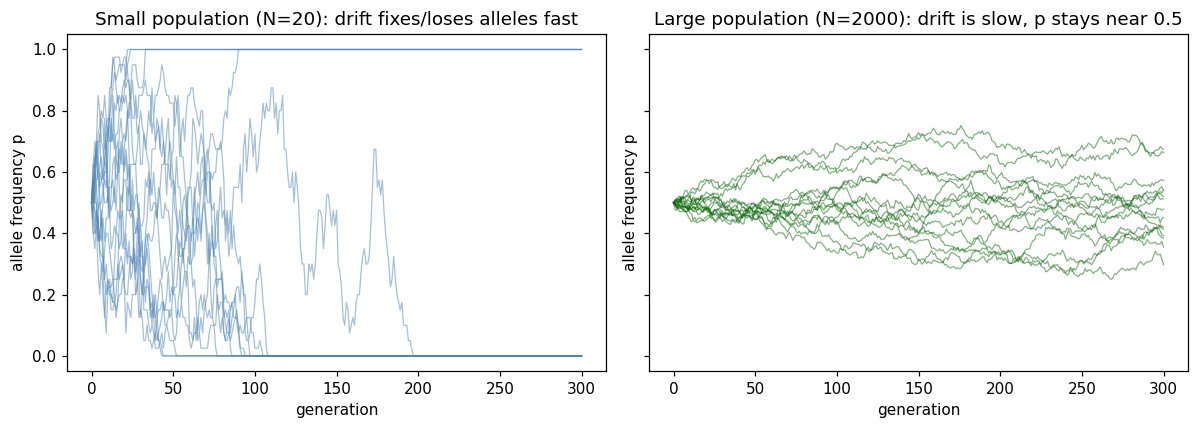

In [5]:
# genetic drift: small populations random-walk to fixation/loss far faster
n_gen = 300
small_trajs = [pg.simulate_genetic_drift(0.5, N=20, n_generations=n_gen, seed=s) for s in range(15)]
large_trajs = [pg.simulate_genetic_drift(0.5, N=2000, n_generations=n_gen, seed=s) for s in range(15)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for traj in small_trajs:
    axes[0].plot(traj, color="steelblue", alpha=0.5, lw=0.8)
axes[0].set_title("Small population (N=20): drift fixes/loses alleles fast")
for traj in large_trajs:
    axes[1].plot(traj, color="darkgreen", alpha=0.5, lw=0.8)
axes[1].set_title("Large population (N=2000): drift is slow, p stays near 0.5")
for ax in axes:
    ax.set_xlabel("generation"); ax.set_ylabel("allele frequency p")
fig.tight_layout()
plt.show()


## 3. A redox electron-transport chain -- the same rate matrix, reused

An electron hopping donor -> intermediate -> acceptor through a redox chain
(e.g. cytochromes passing an electron down a potential gradient) is governed
by the exact same linear ODE $\dot p = Kp$ as FRET energy transfer between
chromophores -- `dgs.photosynthesis_energy_transfer`'s rate-matrix machinery
needs zero modification to model it; only the *interpretation* of the rates
changes (electron-transfer rates instead of FRET rates).


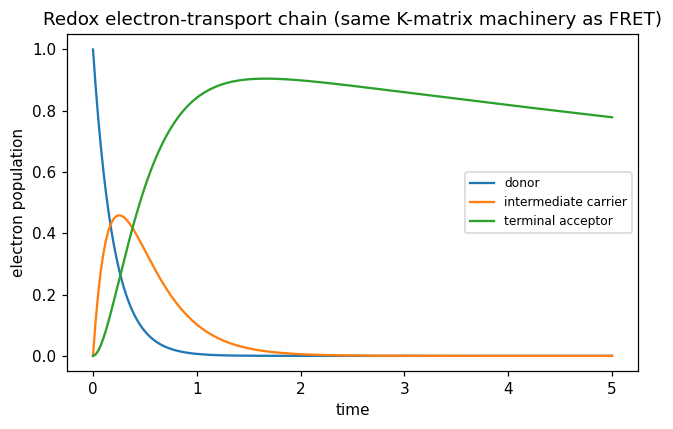

fraction of electrons reaching the terminal acceptor by t=5: 0.7788001874952117


In [6]:
K_redox = pet.build_rate_matrix({(0, 1): 5.0, (1, 2): 3.0}, decay_rates=[0.05, 0.05, 0.05])
t = np.linspace(0, 5, 200)
p0 = [1.0, 0.0, 0.0]   # electron starts on the donor
p_t = pet.solve_population_dynamics(K_redox, p0, t)

plt.figure(figsize=(6, 4))
plt.plot(t, p_t[:, 0], label="donor")
plt.plot(t, p_t[:, 1], label="intermediate carrier")
plt.plot(t, p_t[:, 2], label="terminal acceptor")
plt.xlabel("time"); plt.ylabel("electron population")
plt.title("Redox electron-transport chain (same K-matrix machinery as FRET)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("fraction of electrons reaching the terminal acceptor by t=5:", p_t[-1, 2])


## Summary

The quadrupole's vanishing monopole/dipole and its expansion's convergence
rate were both checked numerically, not just asserted; Hardy-Weinberg's
equilibrium prediction was checked against a deliberately skewed population
and against finite-population Wright-Fisher drift, which shows small
populations losing genetic diversity by chance alone; and the redox electron
chain demonstrates that `photosynthesis_energy_transfer`'s rate-matrix
machinery generalizes to ANY linear multi-step transfer process -- FRET,
electron transport, or otherwise -- for free.
